In [20]:
import pandas as pd
import numpy as np
# from farneback import farneback_optical_flow
from farneback_opt import build_pyr, farneback_optical_flow
from StatTools.generators.ndfnoise_generator import ndfnoise
from StatTools.analysis.dfa import dfa
from StatTools.analysis.utils import analyse_zero_cross_ff
from scipy.stats import linregress
from collections import defaultdict

from StatTools.visualization import plot_ff
from StatTools.analysis.dfa import DFA, dfa
from StatTools.analysis.utils import(
    analyse_cross_ff,
    analyse_cross_ff_linregress,
    cross_fcn_sloped,
    ff_params,
    var_estimation
) 

from joblib import Parallel, delayed, cpu_count
import plotly.express as px
from tqdm import tqdm
from scipy import stats
import matplotlib.pyplot as plt
from typing import Optional
import cv2 as cv
# git clone https://github.com/Digiratory/FluctuationAnalysisTools.git
# cd FluctuationAnalysisTools
# mv StatTools/ ../

In [21]:
def calc_dfa(field, s_values, n_jobs, n_integral):

    def worker(series, n_integral, s_values):
        _, F2_s = dfa(dataset=series,
                    degree=2,
                    s_values=s_values,
                    processes=1,
                    n_integral=n_integral)
        return F2_s
    
    h, w = field.shape[:2]

    tasks = [field[i, j, :] for i in range(h//4, h*3//4) for j in range(w//4, w*3//4)]

    results = Parallel(n_jobs=n_jobs, backend='loky', verbose=0)(
        delayed(worker)(task, n_integral, s_values) for task in tqdm(tasks, desc=f'DFA calc', unit='series')
    )

    F2_s = np.array(results)
    return F2_s
    
def remove_intercept(x ,y):
    linreg = linregress(x, y)
    return y - linreg.intercept

In [37]:
def plot_ff_slopes(
        hs: np.ndarray | None,
        S: np.ndarray,
        ff_parameter: ff_params,
        residuals: np.ndarray | None = None,
        ax=None,
        label:str = None,
        title:str = None,
        linestyle=None,
        color = None
        ):

    hurst = ff_parameter.slopes[0].value
    b = ff_parameter.intercept.value
    if hs is not None:
        hs_array = np.asarray(hs)
        S_new = np.repeat(S[:, np.newaxis], hs_array.shape[0], 1).T
        ax.scatter(S_new, hs_array)
    fit_func = 10 ** (hurst * np.log10(S) + b)
    ax.plot(S, fit_func, label=label, linestyle=linestyle, color=color)
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    if title:
        ax.set_title(title)
    
    ax.grid(which='both', linewidth=0.5)
    return ax


In [ ]:
def run_pipeline(frame_num = 2048, frame_shape = (512, 512), hurst = 1.2, pyr_level=5, n_jobs=24, s_min=10, n_integral=1):
    # make field
    field = ndfnoise(shape=(*frame_shape, frame_num), hurst=hurst, normalize=True)

    mag_result = []
    pyramids = []
    pyramids.append(field)
    for _ in range(4):
        pyramids.append(build_pyr(pyramids[-1], n_jobs=12))

    # calc farneback optical flow
    for pyramid in pyramids:
        mag_result.append(farneback_optical_flow(field=pyramid, n_jobs=12))

    F_s_field_result = []
    
    s_values = np.array([int(np.exp(step)) for step in np.arange(np.log(s_min), np.log(frame_num/5), 0.5)])

    for level in range(pyr_level + 1):
        data_lvl = mag_result[level]
        F2_s_lvl = calc_dfa(data_lvl, s_values, n_jobs, n_integral)
        F_s_lvl = np.sqrt(F2_s_lvl)
        
        # remove intercept and check
        x_log = np.log(np.repeat(s_values[:,np.newaxis], repeats=F_s_lvl.shape[0], axis=-1))
        y_log = np.log(F_s_lvl.T)
        y_log = remove_intercept(x_log, y_log)
        assert np.isclose(linregress(x_log, y_log).intercept, 0).all()

        F_s_lvl = np.exp(y_log).T
        F_s_field_result.append(F_s_lvl)
        
    return F_s_field_result, s_values

In [24]:
hurst_array = np.arange(0.3, 1.5, 0.1).round(1)

pyr_level=4

ff_parameters = defaultdict(list)
for hurst in hurst_array:
    F_s_field_result, s_values = run_pipeline(frame_num=2048,
                                              frame_shape=(512, 512),
                                              hurst=hurst,
                                              pyr_level=pyr_level)

    
    for level in range(pyr_level+1):

        ff_param, _ = analyse_zero_cross_ff(F_s_field_result[level], s_values)
        ff_parameters[hurst].append(ff_param)

DFA calc: 100%|██████████| 256/256 [00:00<00:00, 3547.50series/s]


In [25]:
df = pd.DataFrame(columns=hurst_array.astype(str), index=np.arange(pyr_level+1), dtype=float)
for hurst, ff_list in ff_parameters.items():
    for level, ff_param in enumerate(ff_list):
        df.loc[level, str(hurst)] = ff_param.slopes[0].value

In [26]:
fig = px.imshow(df, text_auto=True, color_continuous_scale='viridis')
fig.show()

# hurst-level

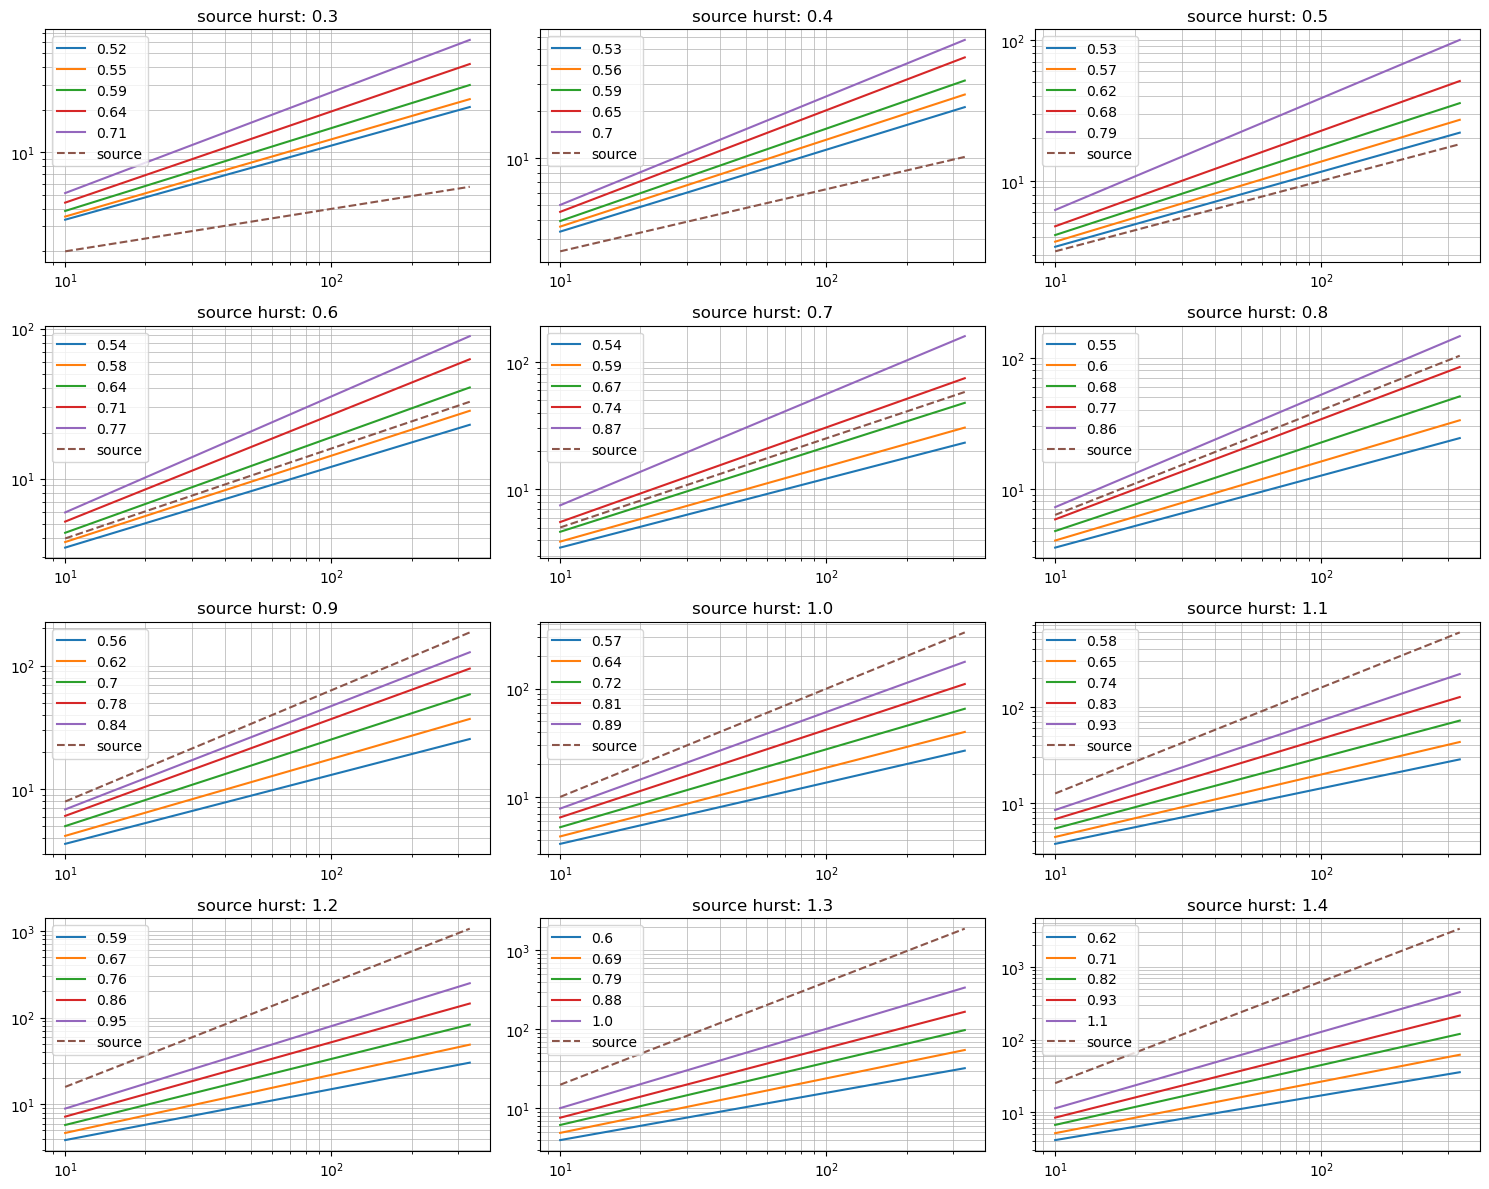

In [51]:
ncols = 3
nrows=np.ceil(len(hurst_array)/ncols).astype(np.int16)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*3))
axes = np.atleast_2d(axes).flatten()
for ax, hurst in zip(axes, ff_parameters.keys()):
    for level, ff_param in enumerate(ff_parameters[hurst]):
        plot_ff_slopes(
            None,
            s_values,
            ff_parameter=ff_param,
            residuals=None,
            ax=ax,
            label = f'{ff_param.slopes[0].value:.2}', 
            title = f'source hurst: {hurst}'
        )
        
    # h source field
    set_h = ff_params(intercept=var_estimation(0.0, 0.0), slopes=[var_estimation(hurst, 0.0)], cross=None, ridigity=None)
    plot_ff_slopes(
            None,
            s_values,
            ff_parameter=set_h,
            residuals=None,
            ax=ax,
            label = f'source', 
            title = f'source hurst: {hurst}',
            linestyle='--'
        )
    ax.legend()   
plt.tight_layout()
plt.show()

# level-hurst

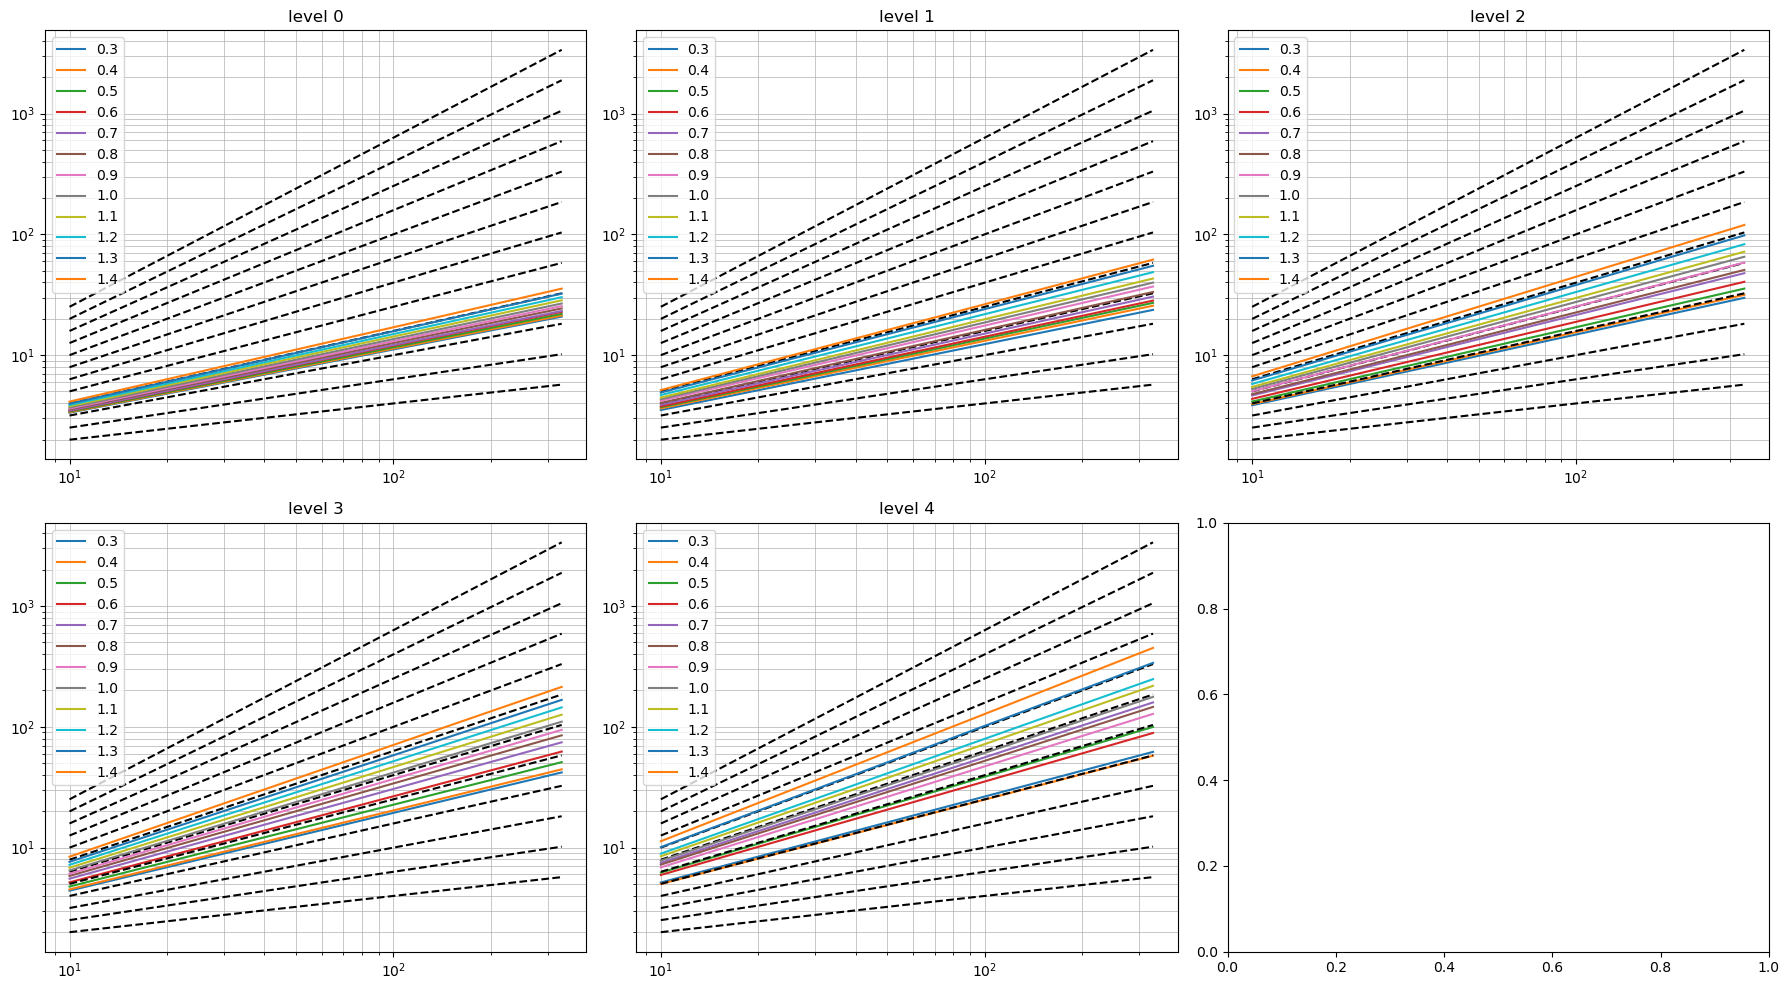

In [44]:
ncols = 3
nrows=np.ceil((pyr_level+1)/ncols).astype(np.int16)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*6, nrows*5))
axes = np.atleast_2d(axes).flatten()
for level, ax in zip(range(pyr_level+1), axes):
    for hurst in ff_parameters.keys():
        ff_param = ff_parameters[hurst][level]
        
        plot_ff_slopes(
            None,
            s_values,
            ff_parameter=ff_param,
            residuals=None,
            ax=ax,
            label = f'{hurst}', 
            title = f'level {level}'
        )
        
        # h source field
        source_h = ff_params(intercept=var_estimation(0.0, 0.0), slopes=[var_estimation(hurst, 0.0)], cross=None, ridigity=None)
        plot_ff_slopes(
                None,
                s_values,
                ff_parameter=source_h,
                residuals=None,
                ax=ax,
                label = '_nolegend_', 
                title = f'level {level}',
                linestyle='--',
                color='k'
            )
        ax.legend()
plt.tight_layout()
plt.show()